In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df = pd.read_csv("C:\\Users\\workstation\\OneDrive\\Afbeeldingen\\library py\\fri_practice\\spam.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [23]:
df['Message'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df['Category'].value_counts()
# Imbalanced Dataset

Category
ham     4825
spam     747
Name: count, dtype: int64

## Imbalanced Data Handling

I tried different techniques to solve the imbalance problem in the dataset such as:

- Oversampling
- Undersampling
- SMOTE
- Class Weight

But after testing the model performance, I noticed that these methods did not improve the results. In some cases, the performance became slightly worse.

So, I decided to continue using the original dataset because it gave better and more stable results.

Text(0.5, 1.0, 'Distribution of ham and spam emails')

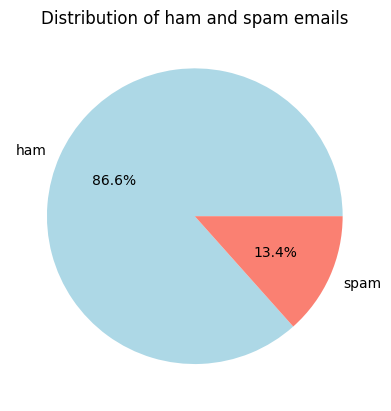

In [26]:
plt.pie(df['Category'].value_counts(), labels=df['Category'].value_counts().index, autopct="%1.1f%%", colors=["lightblue", "salmon"])
plt.title("Distribution of ham and spam emails")

In [27]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [28]:
df["spam"] = df["Category"].replace({"ham":0 , "spam":1})

C:\Users\workstation\AppData\Local\Temp\ipykernel_2260\31075165.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["spam"] = df["Category"].replace({"ham":0 , "spam":1})


In [29]:
df

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will ü b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.Message,df.spam, train_size=.8)

In [31]:
X_test

4178                         Ok lor then we go tog lor...
2887                   No probs hon! How u doinat the mo?
2593    My friend just got here and says he's upping h...
2259    Sad story of a Man - Last week was my b'day. M...
3736                       It‘s £6 to get in, is that ok?
                              ...                        
714     Save yourself the stress. If the person has a ...
1607          Ok no prob... I'll come after lunch then...
5566    REMINDER FROM O2: To get 2.50 pounds free call...
4188                     Dear got bus directly to calicut
2252    hope things went well at 'doctors' ;) reminds ...
Name: Message, Length: 1115, dtype: object

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
X_train_count = v.fit_transform(X_train.values)
X_train_count.toarray()[0].shape

(7805,)

In [33]:
X_train_count.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4457, 7805))

In [34]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_count,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [35]:
emails = [
    'Hey Mohamed, can we get together to watch football game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]
emails_count = v.transform(emails) 
model.predict(emails_count)  

array([0, 1])

In [36]:
X_test_count = v.transform(X_test)
model.score(X_test_count, y_test)

0.9874439461883409

In [37]:
y_predicted = model.predict(X_test_count)
y_predicted

array([0, 0, 0, ..., 1, 0, 0], shape=(1115,))

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       974
           1       0.95      0.95      0.95       141

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



<Axes: >

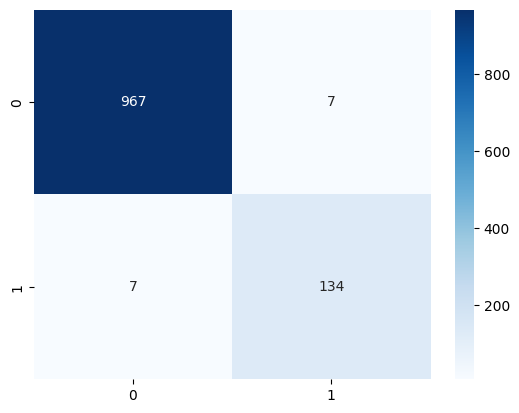

In [39]:
confusion = confusion_matrix(y_test, y_predicted)
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")

In [ ]:
import pickle

with open('naive_bayes_model.pkl', 'wb') as file:
    pickle.dump(model, file)